In [7]:
import geopandas as gpd

gdf = gpd.read_file("data/geojson/CHS_UHF42_Depression_Percent_2017_2018.geojson")
print(gdf.head())
print(gdf.columns)
print(gdf.crs)

   OBJECTID  UHFCODE     SHAPE_Leng    SHAPE_Area                UHF_NEIGH  \
0         1      0.0  207587.595627  2.764099e+08                     None   
1         2    101.0   57699.154353  1.332914e+08  Kingsbridge - Riverdale   
2         3    102.0   88219.319109  1.813708e+08          Northeast Bronx   
3         4    103.0   59711.871991  1.407724e+08     Fordham - Bronx Park   
4         5    104.0  250903.372273  3.865737e+08     Pelham - Throgs Neck   

  BOROUGH Percent_2017_2018_GeoType  Percent_2017_2018_TimePeriodID  \
0     N/A                      None                             NaN   
1   Bronx                     UHF42                           317.0   
2   Bronx                     UHF42                           317.0   
3   Bronx                     UHF42                           317.0   
4   Bronx                     UHF42                           317.0   

   Percent_2017_2018_Value Percent_2017_2018_CI Percent_2017_2018_Note  \
0                      NaN    

In [6]:
gdf.columns


Index(['OBJECTID', 'UHFCODE', 'SHAPE_Leng', 'SHAPE_Area', 'UHF_NEIGH',
       'BOROUGH', 'Percent_2017_2018_GeoType',
       'Percent_2017_2018_TimePeriodID', 'Percent_2017_2018_Value',
       'Percent_2017_2018_CI', 'Percent_2017_2018_Note',
       'Percent_2017_2018_GeoTypeDesc', 'Percent_2017_2018_Geography',
       'Percent_2017_2018_Lat', 'Percent_2017_2018_Long',
       'Percent_2017_2018_TimePeriod', 'Percent_2017_2018_Indicator',
       'geometry'],
      dtype='object')

# Data Preparation

In [ ]:
import utility_func
import pandas as pd
from pathlib import Path
DATA_DIR = Path("data/csv/raw")
files = {
    "air_quality": DATA_DIR / "NYC EH Data Portal - Fine particles (PM 2.5) (filtered).csv",
    "health_insurance": DATA_DIR / "NYC EH Data Portal - Health insurance (adults) (filtered).csv",
    "obesity_adults": DATA_DIR / "NYC EH Data Portal - Obesity (adults) (filtered).csv",
    'personal_doctor': DATA_DIR / "NYC EH Data Portal - Adults with a personal doctor (filtered).csv"
}

# Create a dictionary to hold the cleaned DataFrame for each indicator
indicator_dfs = {}

for indicator, path in files.items():
    df = pd.read_csv(path)
    # Clean the "Percent" column if it exists
    df = utility_func.clean_percent_column(df)
    # Expand rows by geotype if needed
    df = utility_func.expand_rows_by_geotype(df)
    # Optionally normalize TimePeriod string for consistency (if present)
    if "TimePeriod" in df.columns:
        df["TimePeriod"] = df["TimePeriod"].map(utility_func.normalize_time_period)
    df = df.rename(columns={'GeoID': 'UHFCode'})
    indicator_dfs[indicator] = df

for indicator in indicator_dfs:
    print(indicator_dfs[indicator].head())




  TimePeriod GeoTypeDesc  UHFCode  GeoRank  BoroID    Borough  \
0  2021-2022      UHF 42      306        4       3  Manhattan   
1  2021-2022      UHF 42      308        4       3  Manhattan   
2  2021-2022      UHF 42      307        4       3  Manhattan   
3  2021-2022      UHF 42      201        4       2   Brooklyn   
4  2021-2022      UHF 42      309        4       3  Manhattan   

                        Geography                                       Area  \
0               Chelsea - Clinton               Chelsea - Clinton  Manhattan   
1        Greenwich Village - SoHo        Greenwich Village - SoHo  Manhattan   
2     Gramercy Park - Murray Hill     Gramercy Park - Murray Hill  Manhattan   
3                      Greenpoint                       Greenpoint  Brooklyn   
4  Union Square - Lower East Side  Union Square - Lower East Side  Manhattan   

   Annual mean mcg/m3  Summer mean mcg/m3  Winter mean mcg/m3  
0                 8.4                10.4                 8.6  


In [37]:
import pandas as pd
import standardize_data
# Example: load your cleaned combined dataset
depr_df = pd.read_csv("data/csv/clean/uhf42_depression_combined.csv")
# Keep only the two time periods you want
# target = df[df["TimePeriod"].isin(["2017-18", "2021-22"])].copy()
# Pivot so each UHFCode has one row, and periods become columns
wide = depr_df.pivot_table(
    index="UHFCode",   # keep neighborhood name if available
    columns="Year",
    values="DepressionPercentValue",                   # depression percent column
    aggfunc="mean"                    # safe if duplicates exist
).reset_index()
# Build increase column
wide["depression_increase_pct_point"] = wide["2021-2022"] - wide["2017-2018"]
# Final dataframe
depr_increase_df = wide.rename(
    columns={
        "2017-18": "depression_pct_2017_2018",
        "2021-22": "depression_pct_2021_2022"
    }
).sort_values("depression_increase_pct_point", ascending=False)

# Add UHF Name and Borough
uhf_lookup = pd.read_csv("data/csv/clean/UHF42_Classification.csv")

depr_increase_df["UHFCode"] = depr_increase_df["UHFCode"].astype(int)
uhf_lookup["UHFCode"] = uhf_lookup["UHFCode"].astype(int)

depr_increase_df = depr_increase_df.merge(
    uhf_lookup[["UHFCode", "UHF_NEIGH", "Borough"]],
    left_on="UHFCode",
    right_on="UHFCode",
    how="left"
)

depr_increase_df.head()


print(depr_increase_df.head())

   UHFCode  2017-2018  2021-2022  depression_increase_pct_point  \
0      209        6.8       16.3                            9.5   
1      408        9.8       18.6                            8.8   
2      404        4.9       13.7                            8.8   
3      205        8.3       16.3                            8.0   
4      302        8.7       16.3                            7.6   

                              UHF_NEIGH    Borough  
0               Bensonhurst - Bay Ridge   Brooklyn  
1                               Jamaica     Queens  
2                 Bayside - Little Neck     Queens  
3                           Sunset Park   Brooklyn  
4  Central Harlem - Morningside Heights  Manhattan  


# Descriptive Statistics
## Change Plot

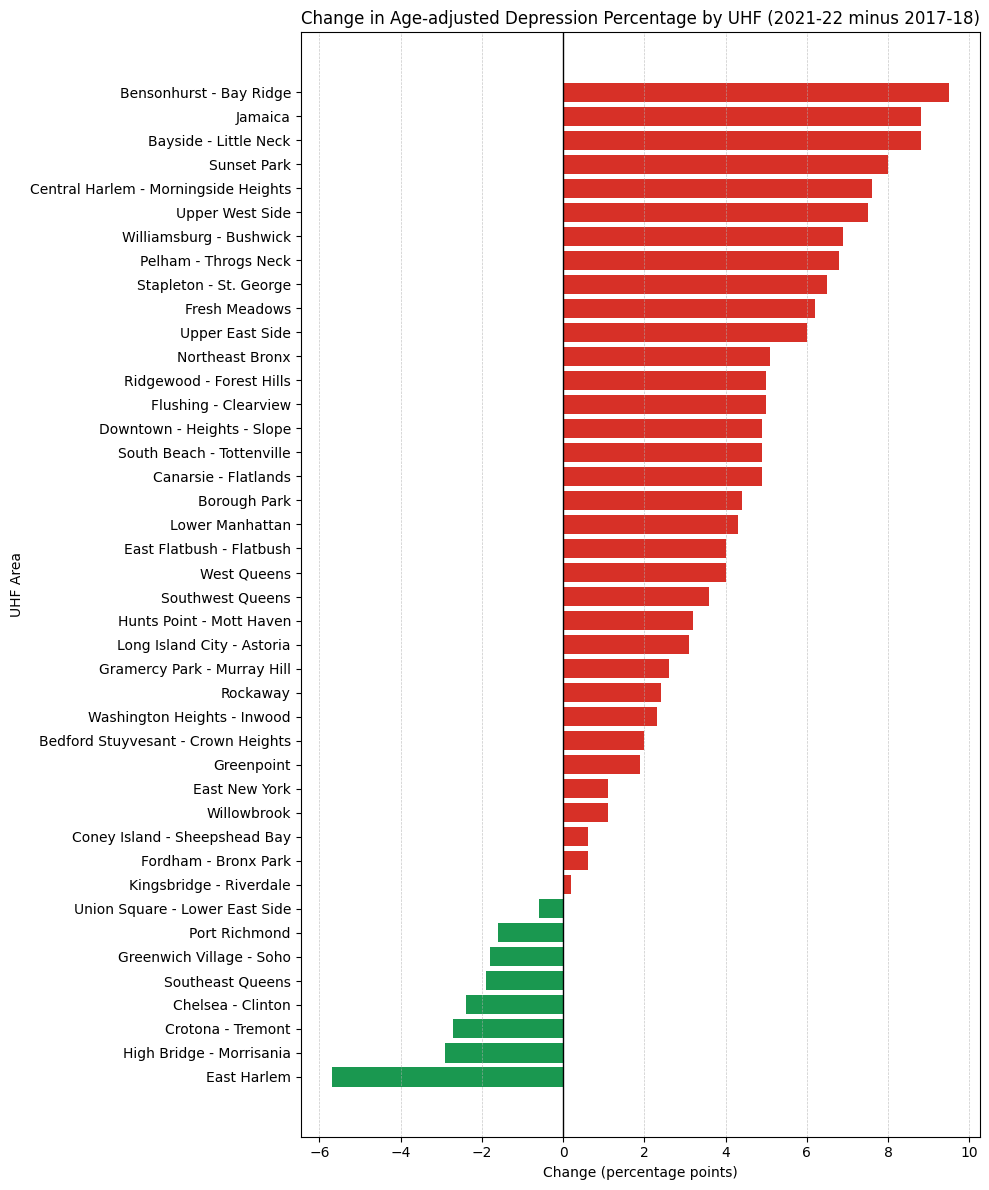

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# assume depr_increase_df has:
# - UHFCode
# - UHF_NEIGH (optional)
# - depression_increase_pct_point

plot_df = depr_increase_df.copy().sort_values("depression_increase_pct_point", ascending=True)
plot_df["label"] = plot_df["UHF_NEIGH"]

plt.figure(figsize=(10, 12))

# color bars by direction of change
colors = plot_df["depression_increase_pct_point"].apply(
    lambda x: "#d73027" if x > 0 else "#1a9850"
)

plt.barh(
    plot_df["label"],
    plot_df["depression_increase_pct_point"],
    color=colors
)
plt.grid(axis='x', linestyle='--', linewidth=0.5, alpha=0.7)

plt.axvline(0, color="black", linewidth=1)
plt.title("Change in Age-adjusted Depression Percentage by UHF (2021-22 minus 2017-18)")
plt.xlabel("Change (percentage points)")
plt.ylabel("UHF Area")
plt.tight_layout()
plt.show()

## Key Stat

In [23]:
import pandas as pd

# --- Prepare Data for Analysis ---
# We need the original 2017-18 and 2021-22 data per UHF

# Assuming you have already loaded 'uhf_lookup' and 'depr_df' previously (or similar); 
# but if not, read in cleaned CSV:
depr_csv = pd.read_csv("data/csv/clean/uhf42_depression_combined.csv")
uhf_lookup = pd.read_csv("data/csv/clean/UHF42_Classification.csv")

# Merge neighborhood info to main depression dataframe
depr_csv = depr_csv.merge(
    uhf_lookup[["UHFCode", "UHF_NEIGH"]],
    left_on="UHFCode",
    right_on="UHFCode",
    how="left"
)

# --- 1. Temporal Change Insights Table: Summary Statistics ---
# Create subset for both years
df_1718 = depr_csv[depr_csv["Year"] == "2017-2018"]
df_2122 = depr_csv[depr_csv["Year"] == "2021-2022"]

def summary_stats(series):
    return {
        "mean": round(series.mean(), 2),
        "median": round(series.median(), 2),
        "IQR": round(series.quantile(0.75) - series.quantile(0.25), 2),
        "Q1": round(series.quantile(0.25), 2),
        "Q3": round(series.quantile(0.75), 2)
    }

stats_17_18 = summary_stats(df_1718["DepressionPercentValue"])
stats_21_22 = summary_stats(df_2122["DepressionPercentValue"])
delta_mean = round(stats_21_22["mean"] - stats_17_18["mean"], 2)
delta_median = round(stats_21_22["median"] - stats_17_18["median"], 2)
delta_iqr = round(stats_21_22["IQR"] - stats_17_18["IQR"], 2)

temporal_change_table = pd.DataFrame({
    "Statistic": ["Mean", "Median", "IQR", "Q1", "Q3"],
    "2017-2018": [stats_17_18["mean"], stats_17_18["median"], stats_17_18["IQR"], stats_17_18["Q1"], stats_17_18["Q3"]],
    "2021-2022": [stats_21_22["mean"], stats_21_22["median"], stats_21_22["IQR"], stats_21_22["Q1"], stats_21_22["Q3"]],
    "Change": [delta_mean, delta_median, delta_iqr, round(stats_21_22["Q1"] - stats_17_18["Q1"],2), round(stats_21_22["Q3"] - stats_17_18["Q3"],2)]
})

print("Temporal Change of Depression Percentage by UHF Area")
display(temporal_change_table)

# --- 3. Ranking: Top Change-UHF Areas Table ---

# Compute change for all UHF areas
uhf_delta = df_1718[["UHFCode", "UHF_NEIGH", "DepressionPercentValue"]].merge(
    df_2122[["UHFCode", "DepressionPercentValue"]],
    on="UHFCode",
    suffixes=("_1718", "_2122")
)
uhf_delta["Change"] = uhf_delta["DepressionPercentValue_2122"] - uhf_delta["DepressionPercentValue_1718"]

top_increase = uhf_delta.sort_values("Change", ascending=False).head(5)
top_decrease = uhf_delta.sort_values("Change").head(5)

print("\nTop 5 Areas with Largest Increases in Depression Percent:")
display(top_increase[["UHF_NEIGH","DepressionPercentValue_1718","DepressionPercentValue_2122","Change"]].rename(columns={
    "DepressionPercentValue_1718":"2017-18", "DepressionPercentValue_2122":"2021-22"
}))



Temporal Change of Depression Percentage by UHF Area


,Statistic,2017-2018,2021-2022,Change
0,Mean,10.13,13.32,3.19
1,Median,9.65,13.25,3.60
2,IQR,5.75,4.67,-1.08
3,Q1,7.05,11.52,4.47
4,Q3,12.80,16.20,3.40



Top 5 Areas with Largest Increases in Depression Percent:


,UHF_NEIGH,2017-18,2021-22,Change
15,Bensonhurst - Bay Ridge,6.8,16.3,9.5
35,Jamaica,9.8,18.6,8.8
31,Bayside - Little Neck,4.9,13.7,8.8
11,Sunset Park,8.3,16.3,8.0
19,Central Harlem - Morningside Heights,8.7,16.3,7.6


# Regression Analysis
## Construct Regression Dataframe

In [ ]:
import pandas as pd
import numpy as np
time_periods = ["2017-2018", "2021-2022"]
UHF_lookup = pd.read_csv("data/csv/clean/UHF42_Classification.csv")
UHFCode_list = UHF_lookup["UHFCode"].tolist()
UHF_Neigh_list = UHF_lookup["UHF_NEIGH"].tolist()

combined_df = pd.DataFrame({
    "TimePeriod": np.repeat(time_periods, len(UHFCode_list)),
    "UHFCode": UHFCode_list * len(time_periods),
    "UHF_NEIGH": UHF_Neigh_list * len(time_periods)
})

combined_df = combined_df.merge(
    indicator_dfs["obesity_adults"][["TimePeriod", "UHFCode", "Percent"]].rename(columns={"Percent": "obesity_percent"}),
    on=["TimePeriod", "UHFCode"],
    how="left"
)

combined_df = combined_df.merge(
    indicator_dfs["air_quality"][["TimePeriod", "UHFCode", "Annual mean mcg/m3"]].rename(columns={"Annual mean mcg/m3": "mean_mcg/m3"}),
    on=["TimePeriod", "UHFCode"],
    how="left"
)

combined_df = combined_df.merge(
    indicator_dfs["health_insurance"][["TimePeriod", "UHFCode", "Percent"]].rename(columns={"Percent": "health_insurance_percent"}),
    on=["TimePeriod", "UHFCode"],
    how="left"
)

combined_df = combined_df.merge(
    depr_df[["Year", "UHFCode", "DepressionPercentValue"]]
        .rename(columns={"Year": "TimePeriod", "DepressionPercentValue": "age_adj_depr_perc"}),
    on=["TimePeriod", "UHFCode"],
    how="left"
)

combined_df = combined_df.merge(
    indicator_dfs["personal_doctor"][["TimePeriod", "UHFCode", "Percent"]].rename(columns={"Percent": "personal_doctor_perc"}),
    on=["TimePeriod", "UHFCode"],
    how="left"
)
# Calculate the change in values between the two time periods for each UHFCode
pivot_cols = ["obesity_percent", "mean_mcg/m3", "health_insurance_percent", "age_adj_depr_perc", "personal_doctor_perc"]
regression_pivot = combined_df.pivot(index=["UHFCode", "UHF_NEIGH"], columns="TimePeriod", values=pivot_cols)
regression_pivot.columns = ['{}_{}'.format(col, period if not isinstance(period, tuple) else period[1])
                            for col, period in regression_pivot.columns]
regression_df = regression_pivot.copy()
for col in pivot_cols:
    col_old = f"{col}_2017-2018"
    col_new = f"{col}_2021-2022"
    regression_df[f"{col}_change"] = regression_df[col_new] - regression_df[col_old]
regression_df = regression_df.reset_index()
regression_df = regression_df[["UHF_NEIGH"] + [f"{col}_change" for col in pivot_cols]]
regression_df = regression_df.rename(columns={
    "obesity_percent_change": "obesity_percent",
    "health_insurance_percent_change": "health_insurance_percent",
    "mean_mcg/m3_change": "mean_mcg/m3",
    "age_adj_depr_perc_change": "age_adj_depr_perc",
    "personal_doctor_perc_change": "personal_doctor_perc"
})
print(regression_df.head())

                 UHF_NEIGH  obesity_percent  mean_mcg/m3  \
0  Kingsbridge - Riverdale              8.2         -0.4   
1          Northeast Bronx              0.9         -0.5   
2     Fordham - Bronx Park             11.4         -0.6   
3     Pelham - Throgs Neck             -1.9         -0.4   
4        Crotona - Tremont              8.4         -0.7   

   health_insurance_percent  age_adj_depr_perc  personal_doctor_perc  
0                      -4.1                0.2                  -3.5  
1                      -3.2                5.1                 -11.1  
2                       2.2                0.6                  -3.4  
3                      -7.3                6.8                 -10.3  
4                      -5.9               -2.7                 -12.2  


In [ ]:
Y = regression_df["age_adj_depr_perc"]
X = regression_df[["obesity_percent", "health_insurance_percent", "mean_mcg/m3", "personal_doctor_perc"]]
import statsmodels.api as sm
X_with_const = sm.add_constant(X)
model = sm.OLS(Y, X_with_const, missing='drop')
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:      age_adj_depr_perc   R-squared:                       0.245
Model:                            OLS   Adj. R-squared:                  0.164
Method:                 Least Squares   F-statistic:                     3.008
Date:                  周四, 26 三月 2026   Prob (F-statistic):             0.0303
Time:                        20:18:08   Log-Likelihood:                -107.62
No. Observations:                  42   AIC:                             225.2
Df Residuals:                      37   BIC:                             233.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   